<a href="https://colab.research.google.com/github/aashikapandey/Data-Science/blob/main/CIFAR10_ANN_CNN_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Step 1: Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

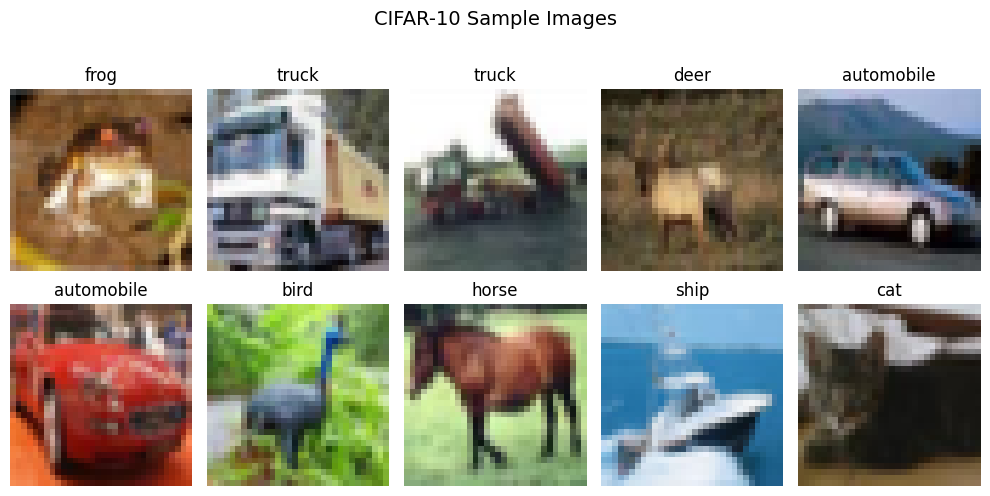

In [3]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.suptitle("CIFAR-10 Sample Images", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 🧹 Step 2: Preprocessing
We normalize pixel values from **0–255 → 0–1** so gradient updates stay stable.

- For **ANN**: We also flatten the 32×32×3 image into a 3072-element vector.
- For **CNN**: We keep the 2D spatial shape intact.

In [4]:
# Normalize: 0-255 → 0.0-1.0
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

# Flatten for ANN (32*32*3 = 3072)
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)

print("Normalized train shape (CNN):", x_train_norm.shape)
print("Flattened train shape  (ANN):", x_train_flat.shape)

Normalized train shape (CNN): (50000, 32, 32, 3)
Flattened train shape  (ANN): (50000, 3072)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    # Task 1: Added extra Dense layers for deeper layout
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),   # extra layer added (Task 1)
    layers.Dense(10, activation='softmax')
], name="ANN")

ann_model.summary()

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ✅ Beginner Task 4 — EarlyStopping integrated
es_ann = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    callbacks=[es_ann]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.2372 - loss: 2.0517 - val_accuracy: 0.3186 - val_loss: 1.9003
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.2875 - loss: 1.9213 - val_accuracy: 0.3234 - val_loss: 1.8753
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - accuracy: 0.3097 - loss: 1.8767 - val_accuracy: 0.3514 - val_loss: 1.8189
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.3200 - loss: 1.8563 - val_accuracy: 0.3296 - val_loss: 1.8701
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3289 - loss: 1.8352 - val_accuracy: 0.3580 - val_loss: 1.7900
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3361 - loss: 1.8156 - val_accuracy: 0.3784 - val_loss: 1.7536
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3450 - loss: 1.7968 - val_accuracy: 0.3874 - val_loss: 1.7368
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.3500 - loss: 1.7830 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3969 - loss: 1.7281
ANN Test Accuracy: 0.3968999981880188


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    # Block 1 — 32 filters: detect low-level edges
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — 64 filters: detect mid-level patterns
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3 — 128 filters: detect high-level features  (Task 2: 32→64→128)
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="CNN")

cnn_model.summary()

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ✅ Beginner Task 4 — EarlyStopping for CNN
es_cnn = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    callbacks=[es_cnn]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 161s 224ms/step - accuracy: 0.4425 - loss: 1.5807 - val_accuracy: 0.5766 - val_loss: 1.2208
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 157s 222ms/step - accuracy: 0.5938 - loss: 1.1444 - val_accuracy: 0.6294 - val_loss: 1.0707
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 198s 216ms/step - accuracy: 0.6629 - loss: 0.9587 - val_accuracy: 0.6260 - val_loss: 1.0740
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 157s 223ms/step - accuracy: 0.7132 - loss: 0.8194 - val_accuracy: 0.6948 - val_loss: 0.9154
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 152s 216ms/step - accuracy: 0.7512 - loss: 0.7100 - val_accuracy: 0.6068 - val_loss: 1.3018
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 157s 223ms/step - accuracy: 0.7822 - loss: 0.6185 - val_accuracy: 0.7460 - val_loss: 0.7753
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 208s 231ms/step - accuracy: 0.8101 - loss: 0.5335 - val_accuracy: 0.7108 - val_loss: 0.9115
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 194s 219ms/step - accuracy: 0.8337 -

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.7403 - loss: 0.8215
CNN Test Accuracy: 0.7402999997138977


## 📈 Compare Learning Curves

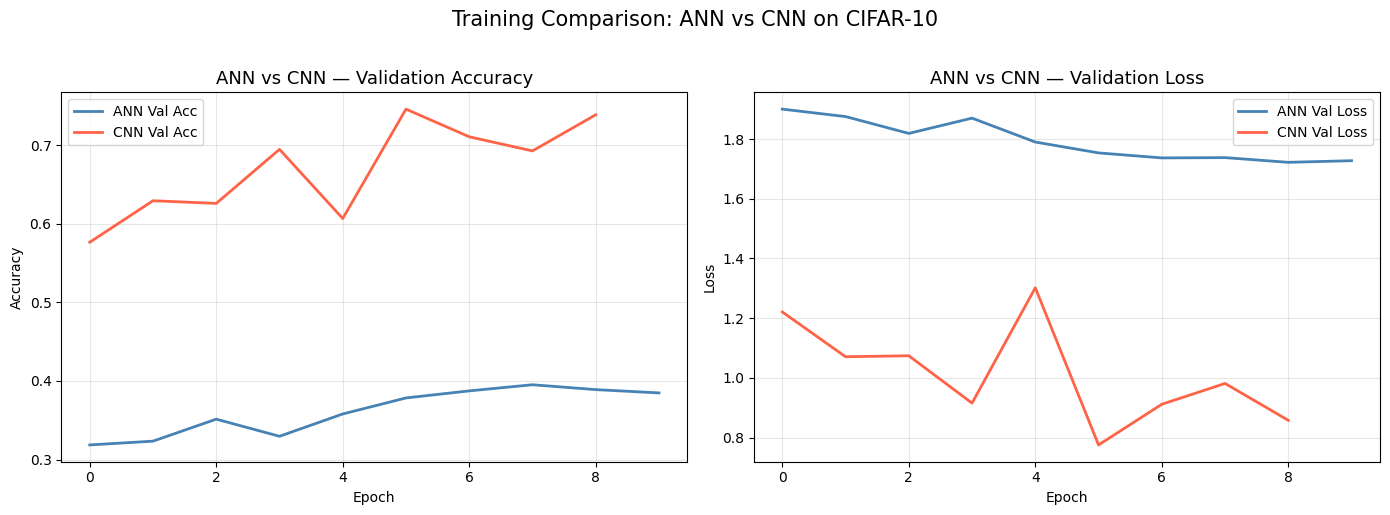

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Validation Accuracy ---
axes[0].plot(ann_history.history['val_accuracy'], label='ANN Val Acc', color='steelblue', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN Val Acc', color='tomato',   linewidth=2)
axes[0].set_title('ANN vs CNN — Validation Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Validation Loss ---
axes[1].plot(ann_history.history['val_loss'], label='ANN Val Loss', color='steelblue', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'], label='CNN Val Loss', color='tomato',   linewidth=2)
axes[1].set_title('ANN vs CNN — Validation Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training Comparison: ANN vs CNN on CIFAR-10', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="augmentation")

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="Augmented_CNN")

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "Augmented_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ✅ Task 3: 20 epochs  |  Task 4: EarlyStopping  |  Task 5: Augmented training RUN
es_aug = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,           # more patience since augmentation slows convergence
    restore_best_weights=True,
    verbose=1
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,                # Task 3: 20 epochs
    validation_split=0.1,
    batch_size=64,
    callbacks=[es_aug]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nAugmented CNN Test Accuracy: {aug_test_acc:.4f}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 176s 239ms/step - accuracy: 0.3430 - loss: 1.8077 - val_accuracy: 0.4232 - val_loss: 1.6750
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 233ms/step - accuracy: 0.4527 - loss: 1.5102 - val_accuracy: 0.5002 - val_loss: 1.5374
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 160s 228ms/step - accuracy: 0.5157 - loss: 1.3645 - val_accuracy: 0.6032 - val_loss: 1.1503
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 232ms/step - accuracy: 0.5613 - loss: 1.2545 - val_accuracy: 0.5950 - val_loss: 1.1794
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 205s 236ms/step - accuracy: 0.5879 - loss: 1.1804 - val_accuracy: 0.5446 - val_loss: 1.4652
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 240ms/step - accuracy: 0.6072 - loss: 1.1317 - val_accuracy: 0.6332 - val_loss: 1.0838
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 233ms/step - accuracy: 0.6276 - loss: 1.0804 - val_accuracy: 0.5834 - val_loss: 1.2099
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 171s 242ms/step - accuracy: 0.6431 -

## 📈 All Three Models — Validation Accuracy Comparison

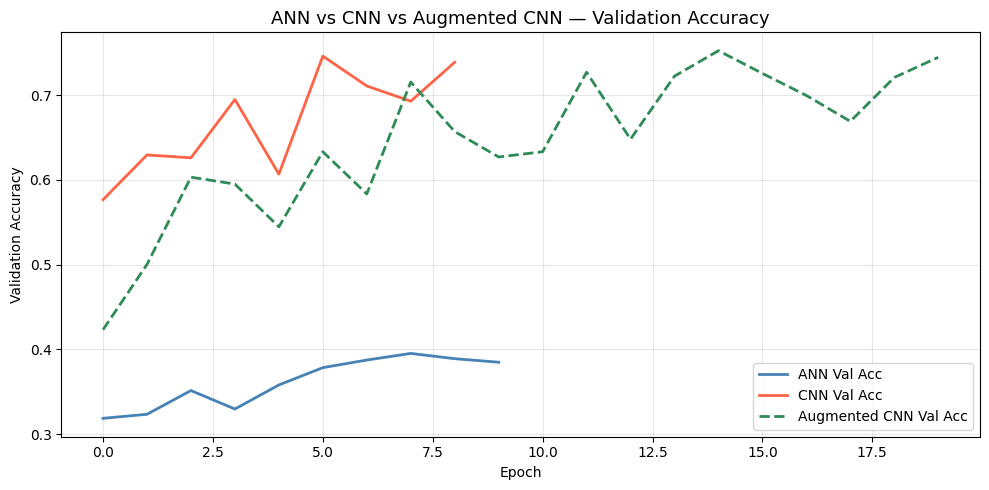

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(ann_history.history['val_accuracy'],     label='ANN Val Acc',          color='steelblue', linewidth=2)
plt.plot(cnn_history.history['val_accuracy'],     label='CNN Val Acc',           color='tomato',   linewidth=2)
plt.plot(aug_history.history['val_accuracy'],     label='Augmented CNN Val Acc', color='seagreen',  linewidth=2, linestyle='--')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('ANN vs CNN vs Augmented CNN — Validation Accuracy', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 📊 Final Comparison Table

In [13]:
comparison = pd.DataFrame({
    "Model":              ["ANN (Deep)",        "CNN (32→64→128)",   "Augmented CNN (20 epochs)"],
    "Architecture":       ["Dense + Dropout",   "Conv2D + BN + Pool", "Augment + Conv2D + BN + Pool"],
    "Epochs Run":         [len(ann_history.history['val_accuracy']),
                           len(cnn_history.history['val_accuracy']),
                           len(aug_history.history['val_accuracy'])],
    "Test Accuracy":      [f"{ann_test_acc:.4f}", f"{cnn_test_acc:.4f}", f"{aug_test_acc:.4f}"],
    "EarlyStopping":      ["✅ Yes",              "✅ Yes",              "✅ Yes (patience=5)"]
})

comparison.style.set_caption("📊 CIFAR-10 Model Comparison")

,Model,Architecture,Epochs Run,Test Accuracy,EarlyStopping
0,ANN (Deep),Dense + Dropout,10,0.3969,✅ Yes
1,CNN (32→64→128),Conv2D + BN + Pool,9,0.7403,✅ Yes
2,Augmented CNN (20 epochs),Augment + Conv2D + BN + Pool,20,0.7416,✅ Yes (patience=5)


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**